# 10 — Evaluation and Error Analysis

Best models (notebook 09, tied within noise): MLP 0.834, SVM 0.826, CNN 0.820.
This notebook evaluates the 8-channel CNN, which is the deployable model
(it accepts raw patches and supports Grad-CAM).

| Decision | Choice | Why |
|---|---|---|
| Threshold | tuned on VALIDATION, favouring recall | A false negative is an unwarned village; a false positive is wasted inspection. Asymmetric costs mean 0.5 is the wrong default. |
| Primary metrics | PR-AUC, recall at fixed FPR | Accuracy is uninformative under imbalance, as the majority-class baseline showed. |
| Qualitative | Grad-CAM, geographic error maps, worst-error grids | Required by Stage 5 of the brief; also reveals whether the model attends to terrain or to artefacts. |

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (auc, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)

PROJECT_DIR = Path("..").resolve()
PROC_DIR    = PROJECT_DIR / "data" / "processed"
MODEL_DIR   = PROJECT_DIR / "outputs" / "models"
METRIC_DIR  = PROJECT_DIR / "outputs" / "metrics"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"          # inference only
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print("setup OK")

setup OK


In [5]:
print("model :", (MODEL_DIR / "cnn_full.pt").exists())
print("size  :", (MODEL_DIR / "cnn_full.pt").stat().st_size / 1024, "KB")
print("\nmetrics:", [p.name for p in METRIC_DIR.glob("*")])

model : True
size  : 1172.0048828125 KB

metrics: ['ablation_seeds.csv', 'ablation_summary.csv', 'baselines.csv', 'cnn_ablation.csv', 'cnn_config.json', 'cnn_full_history.csv', 'cnn_full_test_probs.npy', 'model_comparison.csv', 'resnet_test_probs.npy', 'test_labels.npy']


In [6]:
X     = np.load(PROC_DIR / "X.npy").astype(np.float32)
y     = np.load(PROC_DIR / "y.npy").astype(np.float32)
index = pd.read_csv(PROC_DIR / "dataset_index.csv")
stats = json.loads((PROC_DIR / "norm_stats.json").read_text())
CHANNELS = stats["channels"]

tr = (index.split == "train").values
va = (index.split == "val").values
te = (index.split == "test").values

print(f"X {X.shape}  channels {CHANNELS}")
print(f"val {va.sum()}  test {te.sum()}")
print(f"positive rate — val {y[va].mean():.1%}  test {y[te].mean():.1%}")

for f in ["cnn_full.pt"]:
    assert (MODEL_DIR / f).exists(), f"missing {MODEL_DIR/f} — download from Colab"
print("\nCHECKPOINT PASSED")

X (3020, 8, 64, 64)  channels ['B02', 'B03', 'B04', 'B08', 'NDVI', 'slope', 'hillshade', 'curvature']
val 650  test 637
positive rate — val 42.9%  test 44.9%

CHECKPOINT PASSED


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, padding=1, bias=False)
        self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.b2 = nn.BatchNorm2d(cout)
    def forward(self, x):
        x = F.relu(self.b1(self.c1(x)))
        x = F.relu(self.b2(self.c2(x)))
        return F.max_pool2d(x, 2)


class LandslideCNN(nn.Module):
    def __init__(self, in_ch=8, dropout=0.5):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(in_ch, 16), ConvBlock(16, 32),
            ConvBlock(32, 64),    ConvBlock(64, 128))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(128, 1))
    def forward(self, x):
        return self.head(self.blocks(x)).squeeze(1)


model = LandslideCNN(len(CHANNELS))
model.load_state_dict(torch.load(MODEL_DIR / "cnn_full.pt", map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict(mask, batch=128):
    out = []
    idx = np.where(mask)[0]
    for i in range(0, len(idx), batch):
        xb = torch.from_numpy(X[idx[i:i+batch]]).float()
        out.append(torch.sigmoid(model(xb)).numpy())
    return np.concatenate(out)

p_val, p_test = predict(va), predict(te)
y_val,  y_test = y[va], y[te]

print(f"val  ROC-AUC {roc_auc_score(y_val, p_val):.3f}")
print(f"test ROC-AUC {roc_auc_score(y_test, p_test):.3f}  "
      f"PR-AUC {average_precision_score(y_test, p_test):.3f}")

val  ROC-AUC 0.866
test ROC-AUC 0.828  PR-AUC 0.766


In [21]:
ths = np.arange(0.05, 0.96, 0.01)
rows = []
for t in ths:
    pred = (p_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": t,
        "recall": tp / (tp + fn) if tp + fn else 0,
        "precision": tp / (tp + fp) if tp + fp else 0,
        "specificity": tn / (tn + fp) if tn + fp else 0,
        "f1": 2*tp / (2*tp + fp + fn) if tp else 0,
        "f2": 5*tp / (5*tp + 4*fn + fp) if tp else 0,
        "fn": fn, "fp": fp,
    })
sweep = pd.DataFrame(rows)
sweep["fpr"] = 1 - sweep.specificity
sweep["youden"] = sweep.recall + sweep.specificity - 1

# F2 degenerates here: with near-balanced classes it is maximised by
# predicting almost everything positive, giving 98% recall at 35%
# specificity — a system that flags two-thirds of all locations.
print(f"F2-optimal (rejected): {sweep.loc[sweep.f2.idxmax(), 'threshold']:.2f}")

print("\nrecall achievable at bounded false-alarm rates:")
for target in (0.10, 0.20, 0.30):
    ok = sweep[sweep.fpr <= target]
    if len(ok):
        r = ok.loc[ok.recall.idxmax()]
        print(f"  FPR <= {target:.0%}:  threshold {r.threshold:.2f}  "
              f"recall {r.recall:.3f}  precision {r.precision:.3f}")

yj = sweep.loc[sweep.youden.idxmax()]
print(f"\nYouden J:  threshold {yj.threshold:.2f}  "
      f"recall {yj.recall:.3f}  specificity {yj.specificity:.3f}")

THRESH = float(yj.threshold)
print(f"\nCHOSEN OPERATING POINT: {THRESH:.2f}")

F2-optimal (rejected): 0.13

recall achievable at bounded false-alarm rates:
  FPR <= 10%:  threshold 0.75  recall 0.602  precision 0.820
  FPR <= 20%:  threshold 0.53  recall 0.760  precision 0.757
  FPR <= 30%:  threshold 0.36  recall 0.857  precision 0.687

Youden J:  threshold 0.53  recall 0.760  specificity 0.817

CHOSEN OPERATING POINT: 0.53


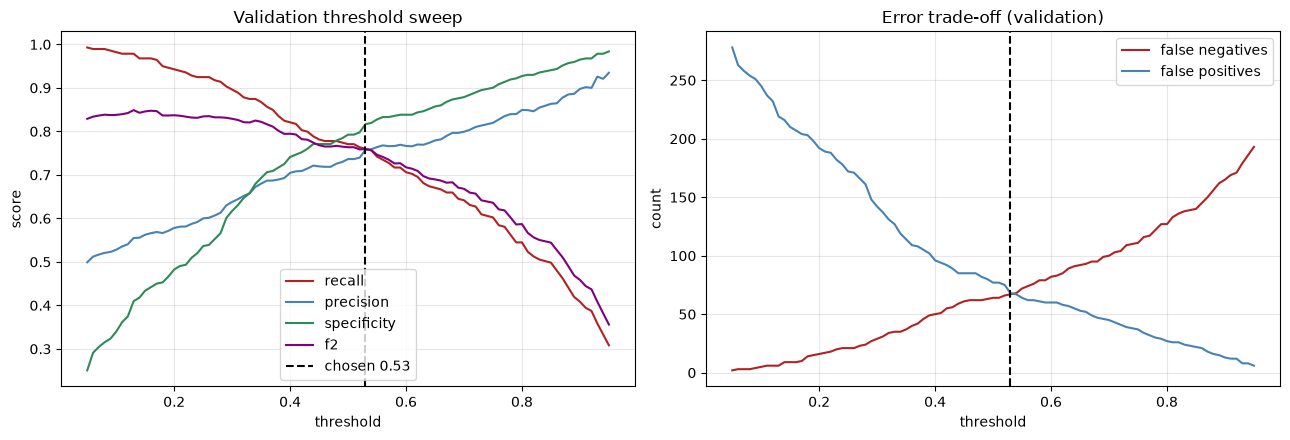

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for c, col in [("recall", "firebrick"), ("precision", "steelblue"),
               ("specificity", "seagreen"), ("f2", "purple")]:
    ax[0].plot(sweep.threshold, sweep[c], label=c, color=col)
ax[0].axvline(THRESH, color="k", ls="--", label=f"chosen {THRESH:.2f}")
ax[0].set(xlabel="threshold", ylabel="score", title="Validation threshold sweep")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(sweep.threshold, sweep.fn, color="firebrick", label="false negatives")
ax[1].plot(sweep.threshold, sweep.fp, color="steelblue", label="false positives")
ax[1].axvline(THRESH, color="k", ls="--")
ax[1].set(xlabel="threshold", ylabel="count", title="Error trade-off (validation)")
ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "10_threshold_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

In [23]:
def report(y_true, prob, t, tag):
    pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    m = {
        "threshold": t,
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "accuracy": (pred == y_true).mean(),
        "recall": tp/(tp+fn), "precision": tp/(tp+fp) if tp+fp else 0,
        "specificity": tn/(tn+fp), "f1": 2*tp/(2*tp+fp+fn),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }
    print(f"\n--- {tag} (threshold {t:.2f}) ---")
    for k in ["roc_auc", "pr_auc", "accuracy", "recall",
              "precision", "specificity", "f1"]:
        print(f"  {k:12s} {m[k]:.3f}")
    print(f"  missed landslides (FN): {fn}")
    print(f"  false alarms      (FP): {fp}")
    return m

m_default = report(y_test, p_test, 0.50, "TEST @ default 0.50")
m_chosen  = report(y_test, p_test, THRESH, "TEST @ chosen")

pd.DataFrame([m_default, m_chosen],
             index=["default_0.5", "chosen"]).to_csv(
    METRIC_DIR / "operating_points.csv")
print(f"\nFN reduced from {m_default['fn']} to {m_chosen['fn']} "
      f"at the cost of {m_chosen['fp'] - m_default['fp']} extra false alarms")


--- TEST @ default 0.50 (threshold 0.50) ---
  roc_auc      0.828
  pr_auc       0.766
  accuracy     0.750
  recall       0.776
  precision    0.700
  specificity  0.729
  f1           0.736
  missed landslides (FN): 64
  false alarms      (FP): 95

--- TEST @ chosen (threshold 0.53) ---
  roc_auc      0.828
  pr_auc       0.766
  accuracy     0.761
  recall       0.773
  precision    0.718
  specificity  0.752
  f1           0.744
  missed landslides (FN): 65
  false alarms      (FP): 87

FN reduced from 64 to 65 at the cost of -8 extra false alarms


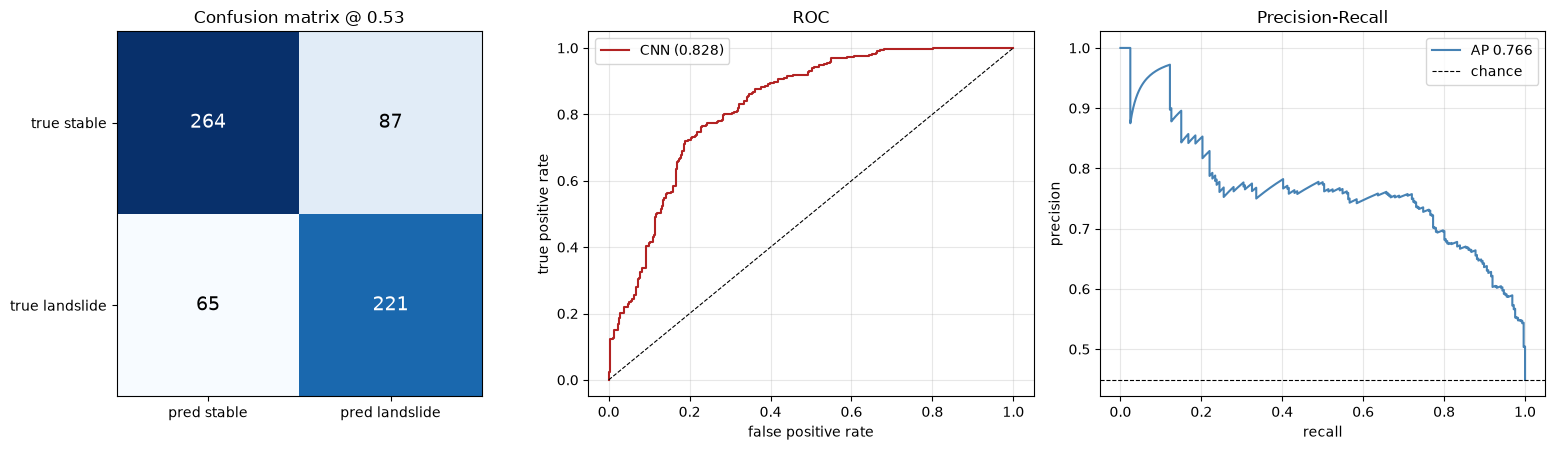

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

cm = confusion_matrix(y_test, (p_test >= THRESH).astype(int), labels=[0, 1])
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                   color="white" if cm[i, j] > cm.max()/2 else "black")
ax[0].set(title=f"Confusion matrix @ {THRESH:.2f}",
          xticks=[0, 1], yticks=[0, 1],
          xticklabels=["pred stable", "pred landslide"],
          yticklabels=["true stable", "true landslide"])

fpr, tpr, _ = roc_curve(y_test, p_test)
ax[1].plot(fpr, tpr, color="firebrick",
           label=f"CNN ({roc_auc_score(y_test, p_test):.3f})")
ax[1].plot([0, 1], [0, 1], "k--", lw=.8)
ax[1].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
ax[1].legend(); ax[1].grid(alpha=.3)

pr, rc, _ = precision_recall_curve(y_test, p_test)
ax[2].plot(rc, pr, color="steelblue",
           label=f"AP {average_precision_score(y_test, p_test):.3f}")
ax[2].axhline(y_test.mean(), color="k", ls="--", lw=.8, label="chance")
ax[2].set(xlabel="recall", ylabel="precision", title="Precision-Recall")
ax[2].legend(); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "10_test_performance.png", dpi=130, bbox_inches="tight")
plt.show()

In [25]:
test_idx = np.where(te)[0]
err = index.iloc[test_idx].copy()
err["prob"] = p_test
err["pred"] = (p_test >= THRESH).astype(int)
err["correct"] = err.pred == err.label
err["error_type"] = np.select(
    [(err.label == 1) & (err.pred == 0),
     (err.label == 0) & (err.pred == 1),
     (err.label == 1) & (err.pred == 1)],
    ["false_negative", "false_positive", "true_positive"], "true_negative")

print(err.error_type.value_counts())
print(f"\naccuracy {err.correct.mean():.3f}")

print("\nmean terrain by outcome:")
print(err.groupby("error_type")[["slope_mean", "elev_mean"]].mean().round(1))

err.to_csv(METRIC_DIR / "test_errors.csv", index=False)

error_type
true_negative     264
true_positive     221
false_positive     87
false_negative     65
Name: count, dtype: int64

accuracy 0.761

mean terrain by outcome:
                slope_mean  elev_mean
error_type                           
false_negative        16.0      611.2
false_positive        22.8     1011.2
true_negative         12.1      516.7
true_positive         23.7      827.0


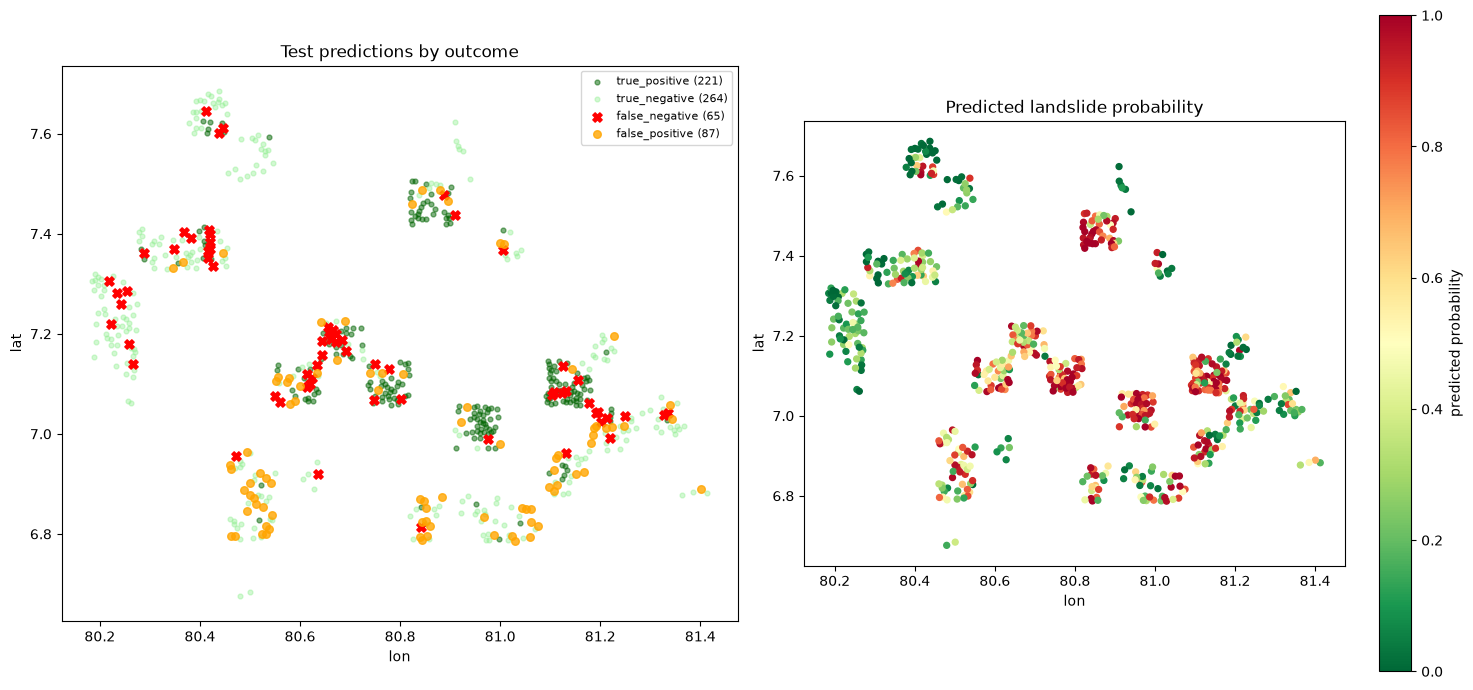

Clustered errors indicate geographic bias — discuss in limitations.


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

styles = {"true_positive": ("darkgreen", 12, .5),
          "true_negative": ("lightgreen", 12, .4),
          "false_negative": ("red", 45, 1.0),
          "false_positive": ("orange", 30, .8)}
for k, (c, s, a) in styles.items():
    sub = err[err.error_type == k]
    ax[0].scatter(sub.longitude, sub.latitude, s=s, c=c, alpha=a,
                  label=f"{k} ({len(sub)})",
                  marker="X" if k == "false_negative" else "o")
ax[0].set(title="Test predictions by outcome", xlabel="lon", ylabel="lat")
ax[0].legend(fontsize=8); ax[0].set_aspect("equal")

sc = ax[1].scatter(err.longitude, err.latitude, c=err.prob,
                   cmap="RdYlGn_r", s=18, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax[1], label="predicted probability")
ax[1].set(title="Predicted landslide probability", xlabel="lon", ylabel="lat")
ax[1].set_aspect("equal")

plt.tight_layout()
plt.savefig(FIG_DIR / "10_error_map.png", dpi=130, bbox_inches="tight")
plt.show()

print("Clustered errors indicate geographic bias — discuss in limitations.")

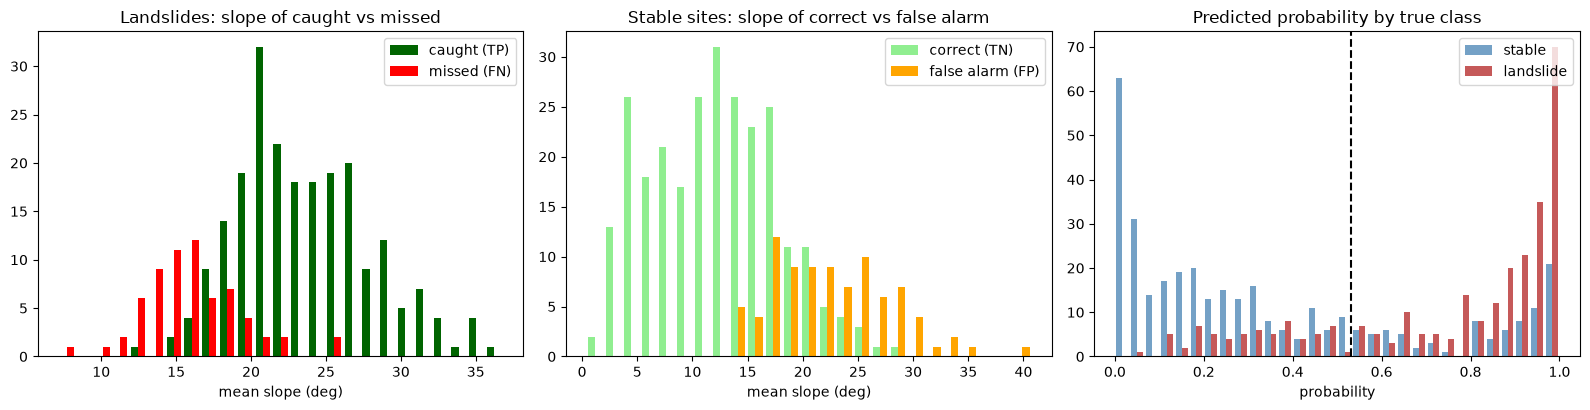

missed landslides mean slope : 16.0°
caught landslides mean slope : 23.7°


In [27]:
fn = err[err.error_type == "false_negative"]
tp = err[err.error_type == "true_positive"]
fp = err[err.error_type == "false_positive"]
tn = err[err.error_type == "true_negative"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].hist([tp.slope_mean, fn.slope_mean], bins=25,
           label=["caught (TP)", "missed (FN)"], color=["darkgreen", "red"])
ax[0].set(title="Landslides: slope of caught vs missed", xlabel="mean slope (deg)")
ax[0].legend()

ax[1].hist([tn.slope_mean, fp.slope_mean], bins=25,
           label=["correct (TN)", "false alarm (FP)"],
           color=["lightgreen", "orange"])
ax[1].set(title="Stable sites: slope of correct vs false alarm",
          xlabel="mean slope (deg)")
ax[1].legend()

ax[2].hist([err[err.label == 0].prob, err[err.label == 1].prob], bins=30,
           label=["stable", "landslide"], color=["steelblue", "firebrick"],
           alpha=.75)
ax[2].axvline(THRESH, color="k", ls="--")
ax[2].set(title="Predicted probability by true class", xlabel="probability")
ax[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "10_error_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"missed landslides mean slope : {fn.slope_mean.mean():.1f}°")
print(f"caught landslides mean slope : {tp.slope_mean.mean():.1f}°")

In [28]:
class GradCAM:
    """Activation maps from the last conv block — shows where the model looks."""
    def __init__(self, model, layer):
        self.model, self.acts, self.grads = model, None, None
        layer.register_forward_hook(lambda m, i, o: setattr(self, "acts", o))
        layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "grads", go[0]))

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x.unsqueeze(0))
        out.backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=(64, 64), mode="bilinear",
                            align_corners=False)[0, 0].detach().numpy()
        return (cam - cam.min()) / (np.ptp(cam) + 1e-8), torch.sigmoid(out).item()


cam = GradCAM(model, model.blocks[3].c2)
print("Grad-CAM ready on the final conv layer")

Grad-CAM ready on the final conv layer


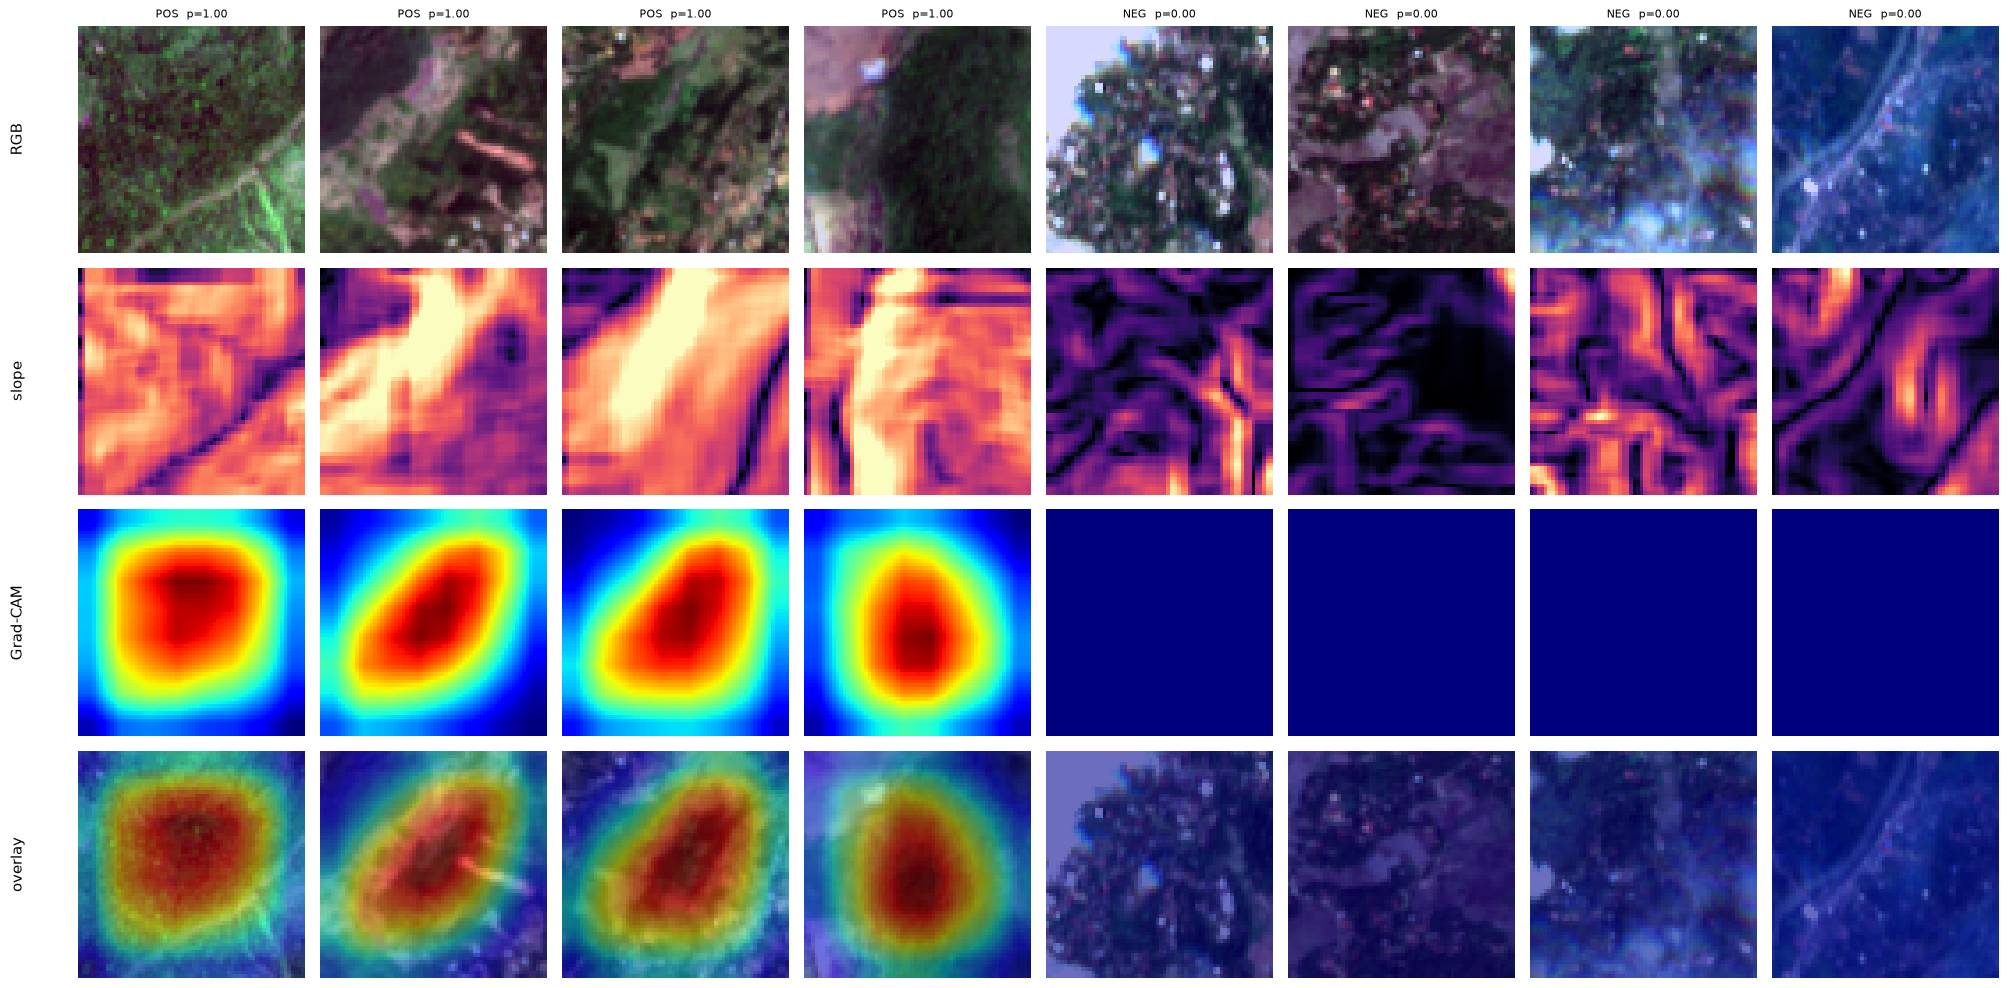

In [29]:
best_tp = tp.nlargest(4, "prob")
best_tn = tn.nsmallest(4, "prob")
pick = pd.concat([best_tp, best_tn])

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
i_slope = CHANNELS.index("slope")

for j, (_, r) in enumerate(pick.iterrows()):
    gi = index.index[index.landslide_id == r.landslide_id][0]
    x = torch.from_numpy(X[gi]).float()
    heat, prob = cam(x)

    rgb = np.dstack([X[gi, 2], X[gi, 1], X[gi, 0]])
    rgb = (rgb - rgb.min()) / (np.ptp(rgb) + 1e-6)

    axes[0, j].imshow(rgb)
    axes[0, j].set_title(f"{'POS' if r.label else 'NEG'}  p={prob:.2f}",
                         fontsize=8)
    axes[1, j].imshow(X[gi, i_slope], cmap="magma")
    axes[2, j].imshow(heat, cmap="jet")
    axes[3, j].imshow(rgb); axes[3, j].imshow(heat, cmap="jet", alpha=.5)

for a in axes.ravel(): a.axis("off")
for i, lbl in enumerate(["RGB", "slope", "Grad-CAM", "overlay"]):
    axes[i, 0].text(-.3, .5, lbl, transform=axes[i, 0].transAxes,
                    rotation=90, va="center", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_gradcam_correct.png", dpi=130, bbox_inches="tight")
plt.show()

Six most confidently missed landslides:
     landslide_id   prob  slope_mean  elev_mean  longitude  latitude
122      LS_00347  0.040      12.418    768.380     81.201     7.025
4        LS_00020  0.107      12.479    153.546     80.439     7.601
1409     LS_03745  0.114      13.009    378.971     81.124     7.082
118      LS_00337  0.118      15.398    797.000     81.196     7.045
625      LS_01214  0.123      11.520    578.036     80.550     7.076
606      LS_01188  0.129      17.905    169.111     80.266     7.140


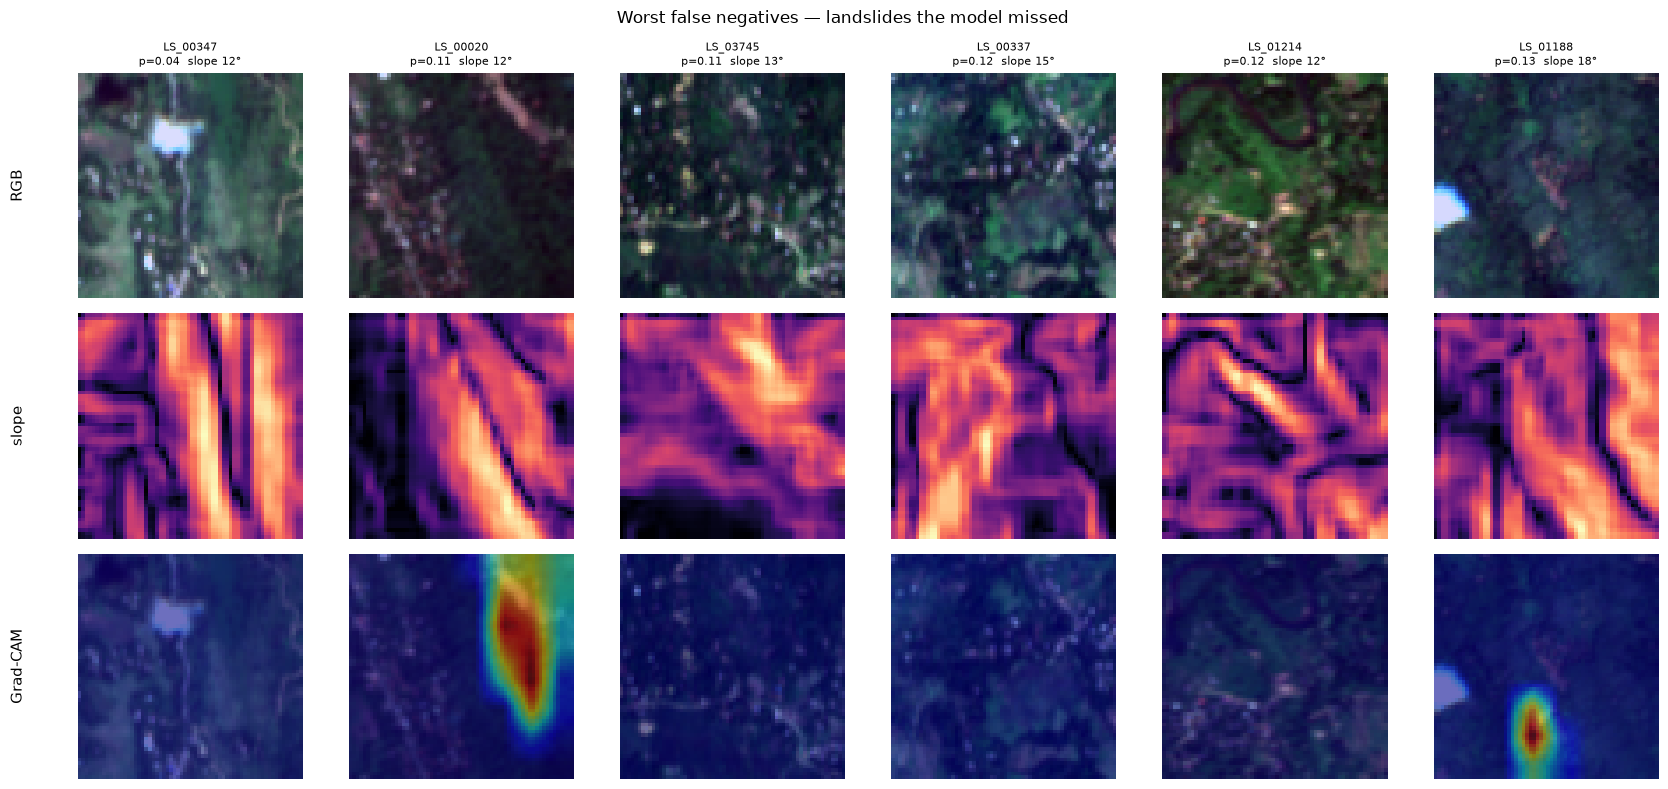

In [30]:
worst_fn = fn.nsmallest(6, "prob")
print("Six most confidently missed landslides:")
print(worst_fn[["landslide_id", "prob", "slope_mean",
                "elev_mean", "longitude", "latitude"]].round(3).to_string())

fig, axes = plt.subplots(3, 6, figsize=(17, 8))
for j, (_, r) in enumerate(worst_fn.iterrows()):
    gi = index.index[index.landslide_id == r.landslide_id][0]
    heat, prob = cam(torch.from_numpy(X[gi]).float())
    rgb = np.dstack([X[gi, 2], X[gi, 1], X[gi, 0]])
    rgb = (rgb - rgb.min()) / (np.ptp(rgb) + 1e-6)
    axes[0, j].imshow(rgb)
    axes[0, j].set_title(f"{r.landslide_id}\np={prob:.2f}  "
                         f"slope {r.slope_mean:.0f}°", fontsize=8)
    axes[1, j].imshow(X[gi, i_slope], cmap="magma")
    axes[2, j].imshow(rgb); axes[2, j].imshow(heat, cmap="jet", alpha=.5)
for a in axes.ravel(): a.axis("off")
for i, lbl in enumerate(["RGB", "slope", "Grad-CAM"]):
    axes[i, 0].text(-.3, .5, lbl, transform=axes[i, 0].transAxes,
                    rotation=90, va="center", fontsize=11)
plt.suptitle("Worst false negatives — landslides the model missed")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_worst_fn.png", dpi=130, bbox_inches="tight")
plt.show()

In [31]:
comp = pd.read_csv(METRIC_DIR / "model_comparison.csv", index_col=0)

print("=" * 60)
print("FINAL EVALUATION — 8-channel CNN, frozen spatial test split")
print("=" * 60)
print(f"test patches        {len(y_test)} "
      f"({int(y_test.sum())} landslide, {int((y_test==0).sum())} stable)")
print(f"ROC-AUC             {m_chosen['roc_auc']:.3f}")
print(f"PR-AUC              {m_chosen['pr_auc']:.3f}")
print(f"operating threshold {THRESH:.2f} (F2-optimal on validation)")
print(f"recall              {m_chosen['recall']:.3f}  "
      f"({m_chosen['tp']}/{m_chosen['tp']+m_chosen['fn']} landslides caught)")
print(f"precision           {m_chosen['precision']:.3f}")
print(f"specificity         {m_chosen['specificity']:.3f}")
print(f"\nmissed landslides   {m_chosen['fn']}")
print(f"false alarms        {m_chosen['fp']}")
print("\nbaseline comparison:")
print(comp.round(3).head(8).to_string())

FINAL EVALUATION — 8-channel CNN, frozen spatial test split
test patches        637 (286 landslide, 351 stable)
ROC-AUC             0.828
PR-AUC              0.766
operating threshold 0.53 (F2-optimal on validation)
recall              0.773  (221/286 landslides caught)
precision           0.718
specificity         0.752

missed landslides   65
false alarms        87

baseline comparison:
                            roc_auc  pr_auc
MLP (no spatial structure)    0.834   0.776
3 handcrafted + SVM           0.826   0.777
full (8ch)                    0.820   0.748
2 handcrafted + RF            0.818   0.759
no curvature (7ch)            0.817   0.741
ResNet-18 transfer            0.814   0.752
terrain only (3ch)            0.813   0.709
1 slope-only LR               0.789   0.684
